In [1]:
# UPI Fraud detection setup 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [5]:
transactions = pd.read_csv(r"D:\Machine Learning\upi_fraud_detection\data\raw\upi_transactions.csv")
users = pd.read_csv(r"D:\Machine Learning\upi_fraud_detection\data\raw\users.csv")

In [6]:
transactions.head()

,transaction_id,timestamp,sender_id,receiver_id,amount,merchant_category,transaction_type,city,latitude,longitude,device_id,upi_channel,fraud_label,fraud_scenario,date,hour,day_of_week,is_weekend,is_late_night
0,TX0150149,2026-01-01 00:05:06,U100666,R99857,1964.88,Ecommerce,P2M,Patna,25.61338,85.12217,D100666,QR,0,normal,2026-01-01,0,Thursday,False,True
1,TX0016422,2026-01-01 00:07:23,U100080,R87314,1965.93,Ecommerce,Bill_Payment,Delhi,28.62374,77.16503,D100080,QR,0,normal,2026-01-01,0,Thursday,False,True
2,TX0045899,2026-01-01 00:23:11,U100214,R65704,33723.94,Utilities,P2P,Jaipur,26.97108,75.79332,D100214,Mobile_Number,0,normal,2026-01-01,0,Thursday,False,True
3,TX0017833,2026-01-01 00:36:36,U100086,R31352,2957.32,Food,P2P,Bengaluru,12.98862,77.59862,D100086,Mobile_Number,0,normal,2026-01-01,0,Thursday,False,True
4,TX0083922,2026-01-01 00:38:45,U100379,R99128,3617.79,Shopping,Recharge,Hyderabad,17.37540,78.53740,D100379,Collect_Request,0,normal,2026-01-01,0,Thursday,False,True


In [7]:
users.head()

,user_id,profile_type,avg_transaction_amount,daily_transaction_rate,home_city,home_lat,home_lon,registered_device
0,U100000,regular,1100.04,1.97,Hyderabad,17.3850,78.4867,D100000
1,U100001,low,392.25,2.06,Kolkata,22.5726,88.3639,D100001
2,U100002,low,679.73,0.85,Hyderabad,17.3850,78.4867,D100002
3,U100003,low,841.82,1.75,Patna,25.5941,85.1376,D100003
4,U100004,regular,3179.77,1.82,Ahmedabad,23.0225,72.5714,D100004


In [8]:
print("Transactions:", transactions.shape)
print("Users:", users.shape)

Transactions: (15000, 19)
Users: (1000, 8)


In [9]:
print("TRANSACTION COLUMNS:")
print(transactions.columns.tolist())

print("\nUSER COLUMNS:")
print(users.columns.tolist())

TRANSACTION COLUMNS:
['transaction_id', 'timestamp', 'sender_id', 'receiver_id', 'amount', 'merchant_category', 'transaction_type', 'city', 'latitude', 'longitude', 'device_id', 'upi_channel', 'fraud_label', 'fraud_scenario', 'date', 'hour', 'day_of_week', 'is_weekend', 'is_late_night']

USER COLUMNS:
['user_id', 'profile_type', 'avg_transaction_amount', 'daily_transaction_rate', 'home_city', 'home_lat', 'home_lon', 'registered_device']


In [10]:
transactions.isnull().sum()

transaction_id       0
timestamp            0
sender_id            0
receiver_id          0
amount               0
merchant_category    0
transaction_type     0
city                 0
latitude             0
longitude            0
device_id            0
upi_channel          0
fraud_label          0
fraud_scenario       0
date                 0
hour                 0
day_of_week          0
is_weekend           0
is_late_night        0
dtype: int64

In [11]:
users.isnull().sum()

user_id                   0
profile_type              0
avg_transaction_amount    0
daily_transaction_rate    0
home_city                 0
home_lat                  0
home_lon                  0
registered_device         0
dtype: int64

In [12]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     15000 non-null  str    
 1   timestamp          15000 non-null  str    
 2   sender_id          15000 non-null  str    
 3   receiver_id        15000 non-null  str    
 4   amount             15000 non-null  float64
 5   merchant_category  15000 non-null  str    
 6   transaction_type   15000 non-null  str    
 7   city               15000 non-null  str    
 8   latitude           15000 non-null  float64
 9   longitude          15000 non-null  float64
 10  device_id          15000 non-null  str    
 11  upi_channel        15000 non-null  str    
 12  fraud_label        15000 non-null  int64  
 13  fraud_scenario     15000 non-null  str    
 14  date               15000 non-null  str    
 15  hour               15000 non-null  int64  
 16  day_of_week        15000 non-null

In [13]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 1000 non-null   str    
 1   profile_type            1000 non-null   str    
 2   avg_transaction_amount  1000 non-null   float64
 3   daily_transaction_rate  1000 non-null   float64
 4   home_city               1000 non-null   str    
 5   home_lat                1000 non-null   float64
 6   home_lon                1000 non-null   float64
 7   registered_device       1000 non-null   str    
dtypes: float64(4), str(4)
memory usage: 88.2 KB


In [14]:
print("Duplicate transactions:",
      transactions.duplicated().sum())

print("Duplicate users:",
      users.duplicated().sum())

Duplicate transactions: 0
Duplicate users: 0


In [15]:
print(
    "Duplicate Transaction IDs:",
    transactions["transaction_id"].duplicated().sum()
)

Duplicate Transaction IDs: 0


In [16]:
print("Amount <= 0:",
      (transactions["amount"] <= 0).sum())

Amount <= 0: 0


In [17]:
transactions["amount"].describe()

count    1.500000e+04
mean     1.046873e+04
std      2.969543e+04
min      6.274000e+01
25%      1.347590e+03
50%      3.432225e+03
75%      9.187312e+03
max      1.397359e+06
Name: amount, dtype: float64

In [18]:
# EDA start actual 

In [19]:
transactions["fraud_label"].value_counts()

fraud_label
0    14250
1      750
Name: count, dtype: int64

In [20]:
# Step 6 — Fraud vs Normal
transactions["fraud_label"].value_counts(normalize=True) * 100

fraud_label
0    95.0
1     5.0
Name: proportion, dtype: float64

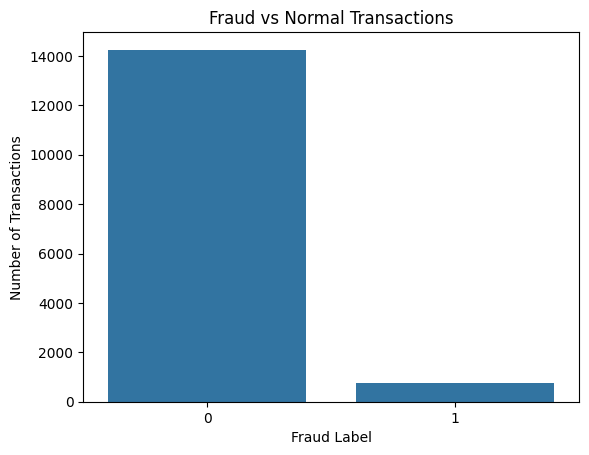

In [21]:
sns.countplot(data=transactions, x="fraud_label")

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Fraud Label")
plt.ylabel("Number of Transactions")
plt.show()

In [22]:
# Step 7 — Fraud Scenarios
transactions["fraud_scenario"].value_counts()

fraud_scenario
normal                 14250
very_high_amount         125
transaction_burst        109
spending_spike           103
new_device                92
late_night                91
failed_then_success       86
new_location              83
repeated_receiver         61
Name: count, dtype: int64

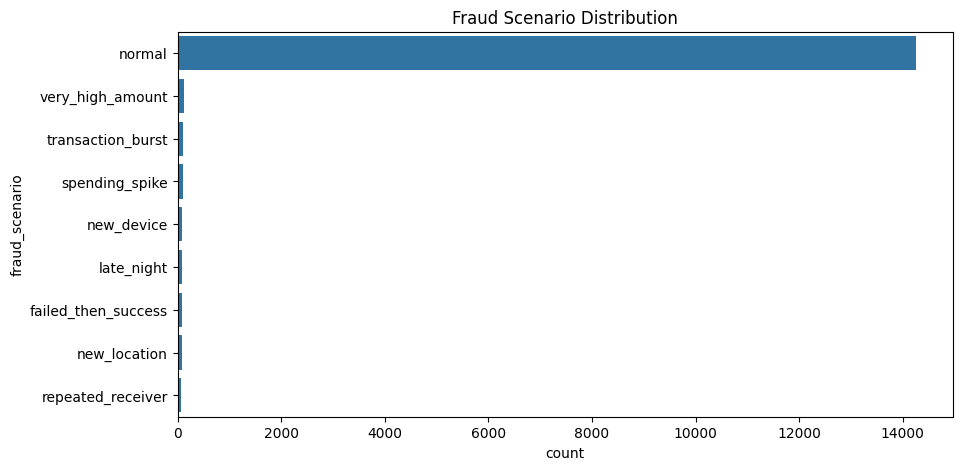

In [23]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=transactions,
    y="fraud_scenario",
    order=transactions["fraud_scenario"].value_counts().index
)

plt.title("Fraud Scenario Distribution")
plt.show()

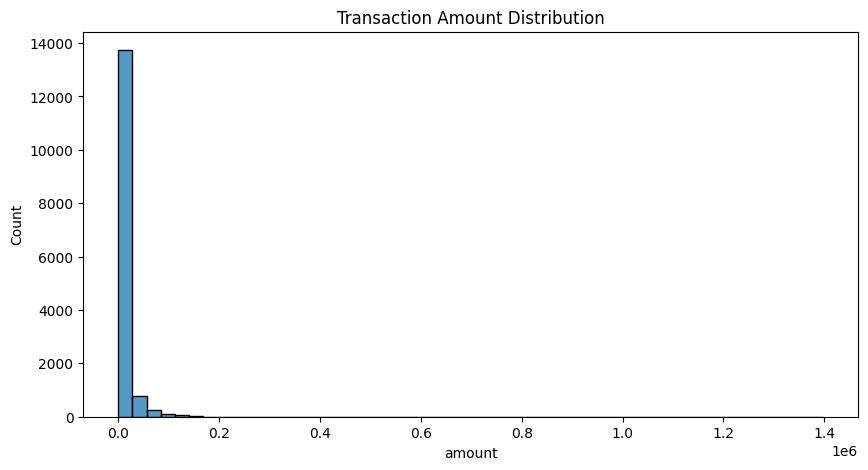

In [24]:
# Step 8 — Transaction Amount
plt.figure(figsize=(10, 5))

sns.histplot(
    data=transactions,
    x="amount",
    bins=50
)

plt.title("Transaction Amount Distribution")
plt.show()

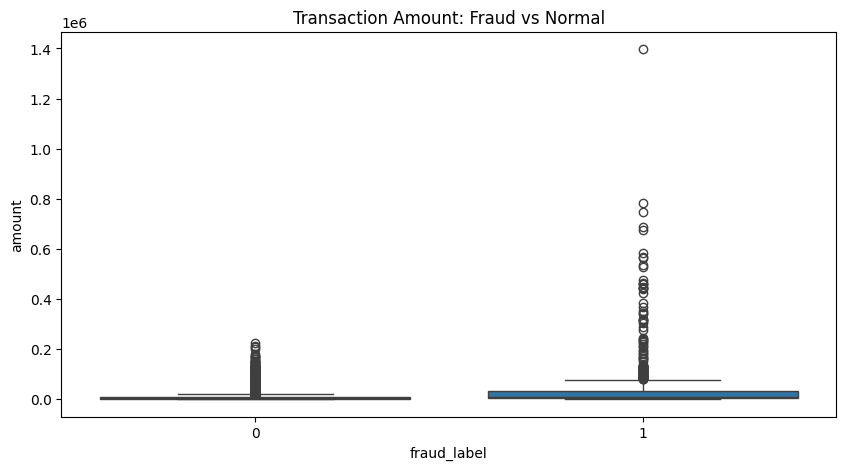

In [25]:
# Fraud vs normal:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=transactions,
    x="fraud_label",
    y="amount"
)

plt.title("Transaction Amount: Fraud vs Normal")
plt.show()

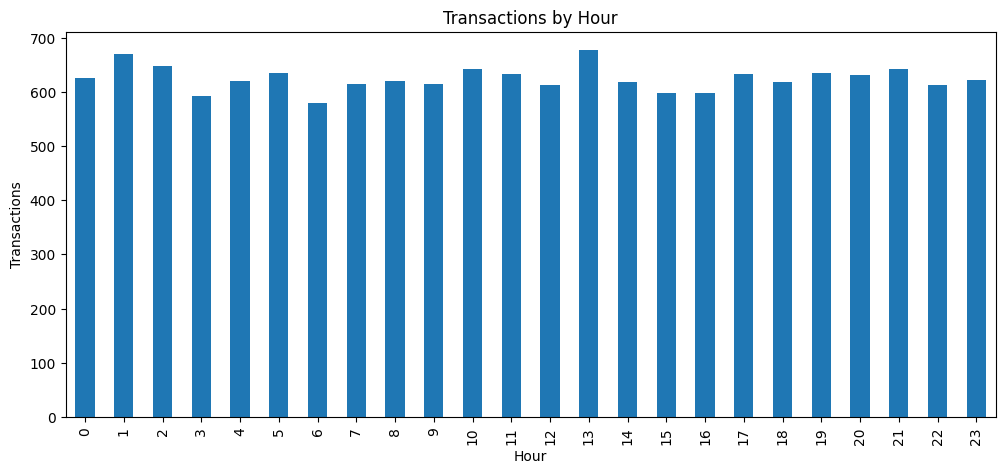

In [26]:
# Step 9 — Transactions by Hour
hourly = transactions["hour"].value_counts().sort_index()

hourly.plot(kind="bar", figsize=(12, 5))

plt.title("Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Transactions")
plt.show()

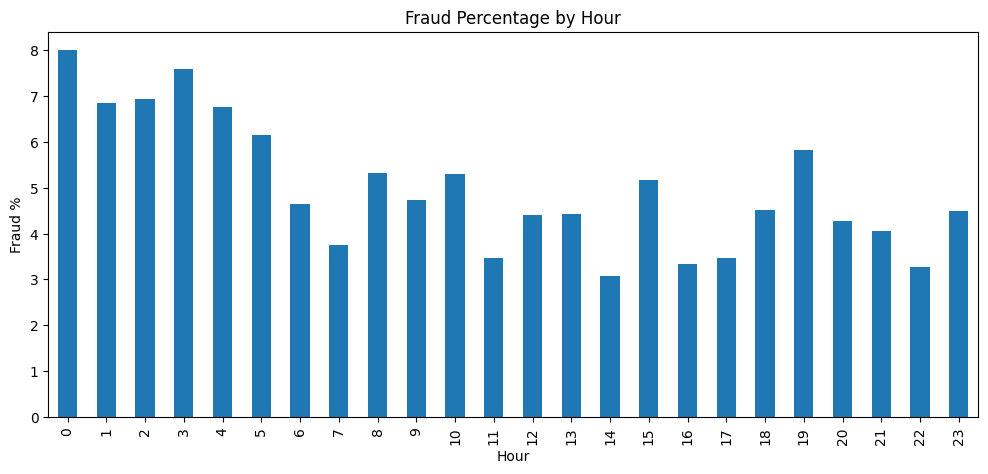

In [27]:
#  Step 10 — Fraud by Hour
fraud_by_hour = (
    transactions
    .groupby("hour")["fraud_label"]
    .mean() * 100
)

fraud_by_hour.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Fraud Percentage by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud %")
plt.show()

In [28]:
#  Step 11 — User Behaviour
user_transaction_count = (
    transactions
    .groupby("sender_id")
    .size()
    .sort_values(ascending=False)
)

user_transaction_count.head(10)

sender_id
U100507    56
U100534    50
U100529    50
U100060    46
U100415    45
U100558    45
U100247    45
U100694    44
U100572    43
U100945    43
dtype: int64

In [29]:
user_avg_spending = (
    transactions
    .groupby("sender_id")["amount"]
    .mean()
    .sort_values(ascending=False)
)

user_avg_spending.head(10)

sender_id
U100295    120606.238387
U100167     92245.937037
U100527     71539.066154
U100418     70578.762051
U100958     69751.972105
U100689     66549.007000
U100719     66017.955333
U100060     64716.771304
U100569     62949.793846
U100816     62932.430938
Name: amount, dtype: float64

In [30]:
#  Step 12 — Users + Transactions JOIN
user_history = transactions.merge(
    users,
    left_on="sender_id",
    right_on="user_id",
    how="left"
)

user_history.head()

,transaction_id,timestamp,sender_id,receiver_id,amount,merchant_category,transaction_type,city,latitude,longitude,device_id,upi_channel,fraud_label,fraud_scenario,date,hour,day_of_week,is_weekend,is_late_night,user_id,profile_type,avg_transaction_amount,daily_transaction_rate,home_city,home_lat,home_lon,registered_device
0,TX0150149,2026-01-01 00:05:06,U100666,R99857,1964.88,Ecommerce,P2M,Patna,25.61338,85.12217,D100666,QR,0,normal,2026-01-01,0,Thursday,False,True,U100666,regular,1672.84,2.48,Patna,25.5941,85.1376,D100666
1,TX0016422,2026-01-01 00:07:23,U100080,R87314,1965.93,Ecommerce,Bill_Payment,Delhi,28.62374,77.16503,D100080,QR,0,normal,2026-01-01,0,Thursday,False,True,U100080,regular,3206.72,2.40,Delhi,28.6139,77.2090,D100080
2,TX0045899,2026-01-01 00:23:11,U100214,R65704,33723.94,Utilities,P2P,Jaipur,26.97108,75.79332,D100214,Mobile_Number,0,normal,2026-01-01,0,Thursday,False,True,U100214,business,23530.58,5.31,Jaipur,26.9124,75.7873,D100214
3,TX0017833,2026-01-01 00:36:36,U100086,R31352,2957.32,Food,P2P,Bengaluru,12.98862,77.59862,D100086,Mobile_Number,0,normal,2026-01-01,0,Thursday,False,True,U100086,regular,4703.06,1.86,Bengaluru,12.9716,77.5946,D100086
4,TX0083922,2026-01-01 00:38:45,U100379,R99128,3617.79,Shopping,Recharge,Hyderabad,17.37540,78.53740,D100379,Collect_Request,0,normal,2026-01-01,0,Thursday,False,True,U100379,regular,2693.02,3.37,Hyderabad,17.3850,78.4867,D100379


In [31]:
#  Step 13 — Clean Dataset save karo

transactions["timestamp"] = pd.to_datetime(
    transactions["timestamp"]
)

In [32]:
transactions = transactions.sort_values("timestamp")

In [33]:
transactions.to_csv(
    r"D:\Machine Learning\upi_fraud_detection\data\processed\transactions_clean.csv",
    index=False
)

In [34]:
users.to_csv(
    r"D:\Machine Learning\upi_fraud_detection\data\processed\users_clean.csv",
    index=False
)